In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_parquet('../data/processed/master_feature_table.parquet')
print(df.shape)
df.head()

(13638, 30)


,date,game_number,season,home_team,away_team,home_score,away_score,home_team_won,game_pk,home_starter_id,...,home_starter_whip_entering_game_last3,home_starter_fip_entering_game_last3,home_starter_whip_entering_game_last5,home_starter_fip_entering_game_last5,away_starter_whip_entering_game_season,away_starter_fip_entering_game_season,away_starter_whip_entering_game_last3,away_starter_fip_entering_game_last3,away_starter_whip_entering_game_last5,away_starter_fip_entering_game_last5
0,2021-04-01,1,2021,CHC,PIT,3.0,5.0,0,634634,543294,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-04-01,1,2021,CIN,STL,6.0,11.0,0,634636,622491,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-04-01,1,2021,COL,LAD,8.0,5.0,1,634615,608566,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-04-01,1,2021,DET,CLE,3.0,2.0,1,634645,571510,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-04-01,1,2021,KCR,TEX,14.0,10.0,1,634630,641745,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


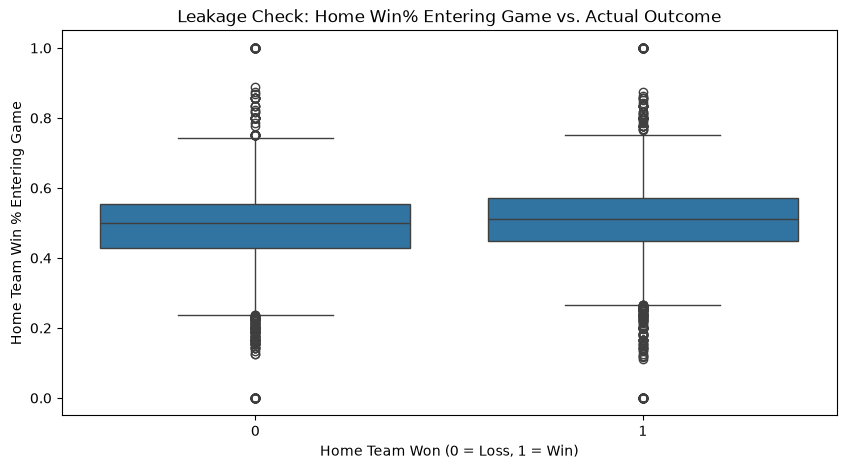

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='home_team_won', y='home_win_pct_entering')
plt.xlabel('Home Team Won (0 = Loss, 1 = Win)')
plt.ylabel('Home Team Win % Entering Game')
plt.title('Leakage Check: Home Win% Entering Game vs. Actual Outcome')
plt.show()
# Leakage sanity check #1: home team win% entering the game vs. actual outcome.
# Expectation: a real but modest separation between the two groups — teams
# with better rolling win% should win somewhat more often, but the
# distributions should still overlap heavily, since a single pre-game
# stat should never near-perfectly predict a game's outcome on its own.
# Result: confirmed — median win% is slightly higher in the "won" group,
# with substantial overlap between both distributions. No sign of leakage.

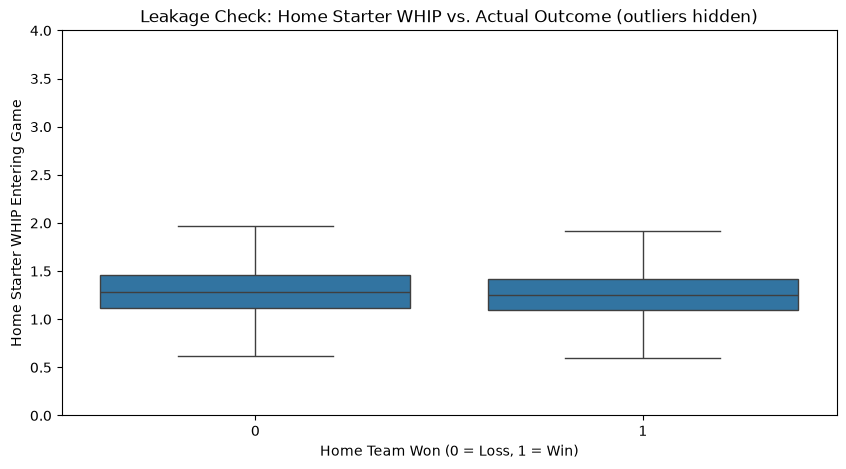

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='home_team_won', y='home_starter_whip_entering_game_season', showfliers=False)
plt.ylim(0, 4)
plt.xlabel('Home Team Won (0 = Loss, 1 = Win)')
plt.ylabel('Home Starter WHIP Entering Game')
plt.title('Leakage Check: Home Starter WHIP vs. Actual Outcome (outliers hidden)')
plt.show()
# Leakage sanity check #2: home starting pitcher's season WHIP entering the
# game vs. actual outcome. WHIP is inverted relative to win% (lower = better
# pitcher), so the expected direction is the opposite: a LOWER median WHIP
# in the "won" group. Outliers hidden (showfliers=False) and y-axis capped
# at 4 — a handful of pitchers with very few innings pitched in their early-
# season sample produce extreme WHIP ratios (e.g. ~21) that would otherwise
# dominate the chart and obscure the real distribution.
# Result: confirmed — median WHIP is slightly lower in the "won" group, with
# a comparable effect size to the win% chart. Consistent with real signal,
# not leakage.

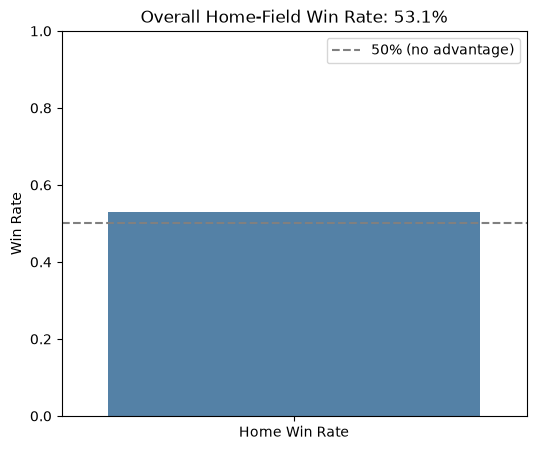

In [ ]:
overall_home_win_rate = df['home_team_won'].mean()

plt.figure(figsize=(6, 5))
sns.barplot(x=['Home Win Rate'], y=[overall_home_win_rate], color='steelblue')
plt.axhline(0.5, color='gray', linestyle='--', label='50% (no advantage)')
plt.ylim(0, 1)
plt.ylabel('Win Rate')
plt.title(f'Overall Home-Field Win Rate: {overall_home_win_rate:.1%}')
plt.legend()
plt.show()
# Confirms the ~54% MLB home-field advantage baseline referenced throughout
# this project. Matches the raw home_team_won.mean() check run earlier
# (53.05%) — this chart is a visual restatement of that number, not new
# information, but useful as a reference point for the by-team breakdown.

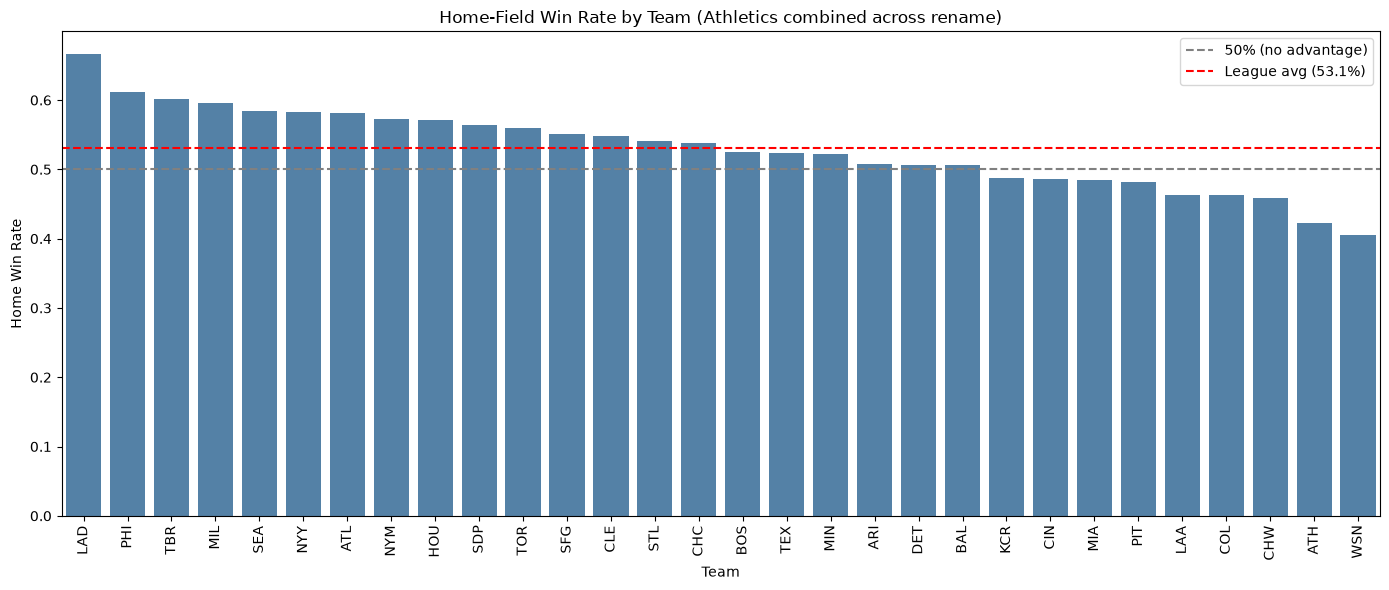

In [16]:
df_display = df.copy()
df_display['home_team_display'] = df_display['home_team'].replace({'OAK': 'ATH'})

team_home_win_rate = df_display.groupby('home_team_display')['home_team_won'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(x=team_home_win_rate.index, y=team_home_win_rate.values, color='steelblue')
plt.axhline(0.5, color='gray', linestyle='--', label='50% (no advantage)')
plt.axhline(overall_home_win_rate, color='red', linestyle='--', label=f'League avg ({overall_home_win_rate:.1%})')
plt.xticks(rotation=90)
plt.ylabel('Home Win Rate')
plt.xlabel('Team')
plt.title('Home-Field Win Rate by Team (Athletics combined across rename)')
plt.legend()
plt.tight_layout()
plt.show()
# Home win rate varies meaningfully by team — from ~40% (WSN) to ~67% (LAD)
# Consistent with real differences in park factors and team strength over
# this sample period.

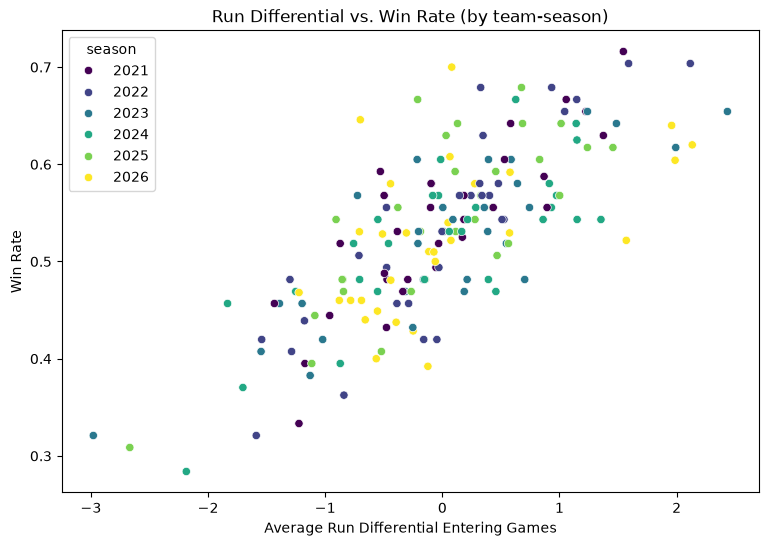

In [ ]:
team_season_stats = df.groupby(['home_team', 'season']).agg(
    win_rate=('home_team_won', 'mean'),
    avg_run_diff=('home_run_diff_entering', 'mean')
).reset_index()

plt.figure(figsize=(9, 6))
sns.scatterplot(data=team_season_stats, x='avg_run_diff', y='win_rate', hue='season', palette='viridis')
plt.xlabel('Average Run Differential Entering Games')
plt.ylabel('Win Rate')
plt.title('Run Differential vs. Win Rate (by team-season)')
plt.show()
# Run differential shows a clear positive relationship with win rate, as
# expected — this is one of the most well-established relationships in
# baseball analytics, and its clear presence here is a good sign that
# home_run_diff_entering was computed correctly. Points cluster fairly
# tightly around an upward trend across all 6 seasons, with 2026 (yellow)
# showing more spread due to being a partial season with fewer games per
# team-season data point.

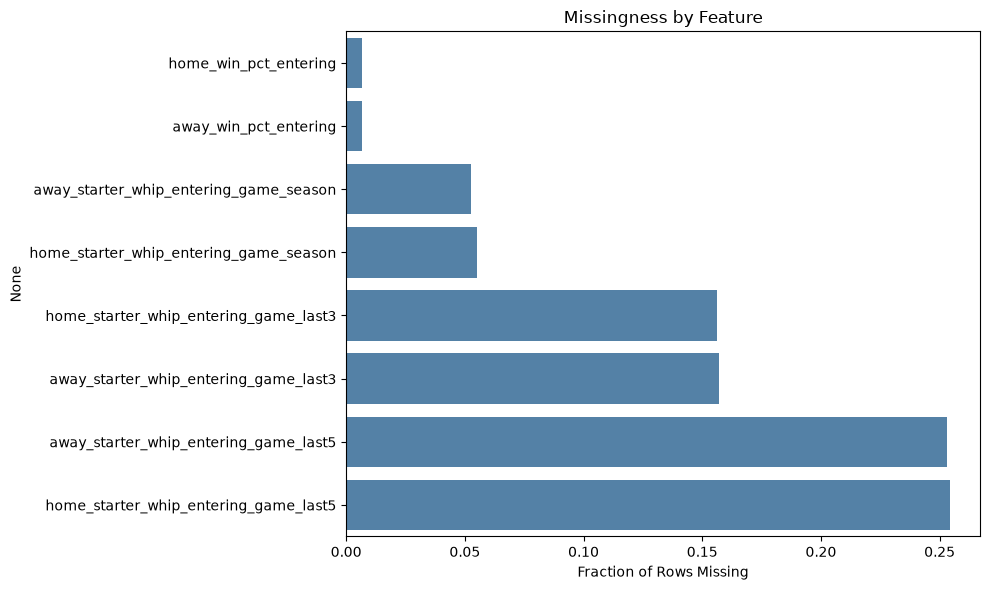

In [ ]:
feature_cols = [
    'home_win_pct_entering', 'away_win_pct_entering',
    'home_starter_whip_entering_game_season', 'away_starter_whip_entering_game_season',
    'home_starter_whip_entering_game_last3', 'away_starter_whip_entering_game_last3',
    'home_starter_whip_entering_game_last5', 'away_starter_whip_entering_game_last5',
]

null_rates = df[feature_cols].isna().mean().sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=null_rates.values, y=null_rates.index, color='steelblue')
plt.xlabel('Fraction of Rows Missing')
plt.title('Missingness by Feature')
plt.tight_layout()
plt.show()
# Missingness climbs in the exact order we'd expect: win% (~0.6%) < season
# WHIP (~5%) < last-3 WHIP (~15-16%) < last-5 WHIP (~25%). This matches the
# numeric NaN check run earlier in the pipeline almost exactly, and makes
# intuitive sense — a stat needing more prior starts before it can compute
# will always have more missing values early in a pitcher's season. No
# surprises here; this confirms the rolling logic is behaving consistently
# at full scale, not just on the small samples tested during development.

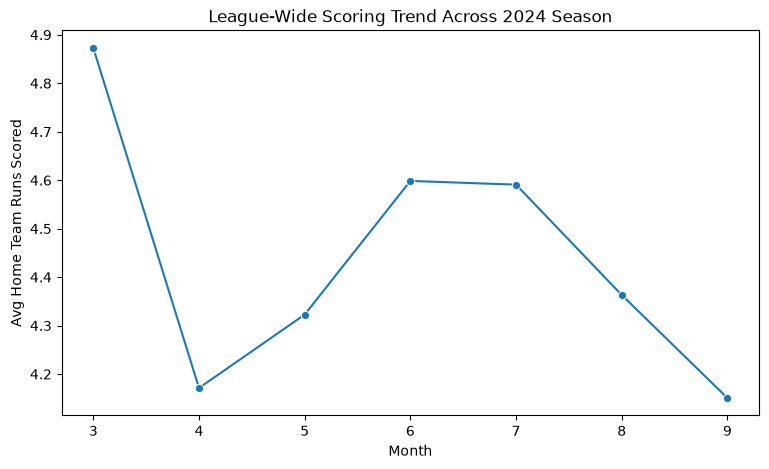

In [ ]:
season_data = df[df['season'] == 2024].copy()
season_data['month'] = pd.to_datetime(season_data['date']).dt.month

monthly_runs = season_data.groupby('month')['home_score'].mean()

plt.figure(figsize=(9, 5))
sns.lineplot(x=monthly_runs.index, y=monthly_runs.values, marker='o')
plt.xlabel('Month')
plt.ylabel('Avg Home Team Runs Scored')
plt.title('League-Wide Scoring Trend Across 2024 Season')
plt.show()
# Scoring dips in April, climbs through mid-summer, and falls off in
# September — plausible in isolation (weather/pitcher form). But the March
# data point (4.87 runs) is the highest of the whole season, which doesn't
# have an obvious baseball explanation on its own.
#
# Likely cause: the 2024 season started March 28 — so "March" here is
# really only 3-4 days of games, not a full month. A handful of high-
# scoring season-openers can swing that single point noticeably, since the
# sample size for that bucket is tiny compared to every other month. This
# is a small-sample artifact of the monthly grouping, not a real seasonal
# scoring pattern — worth noting rather than reading into.

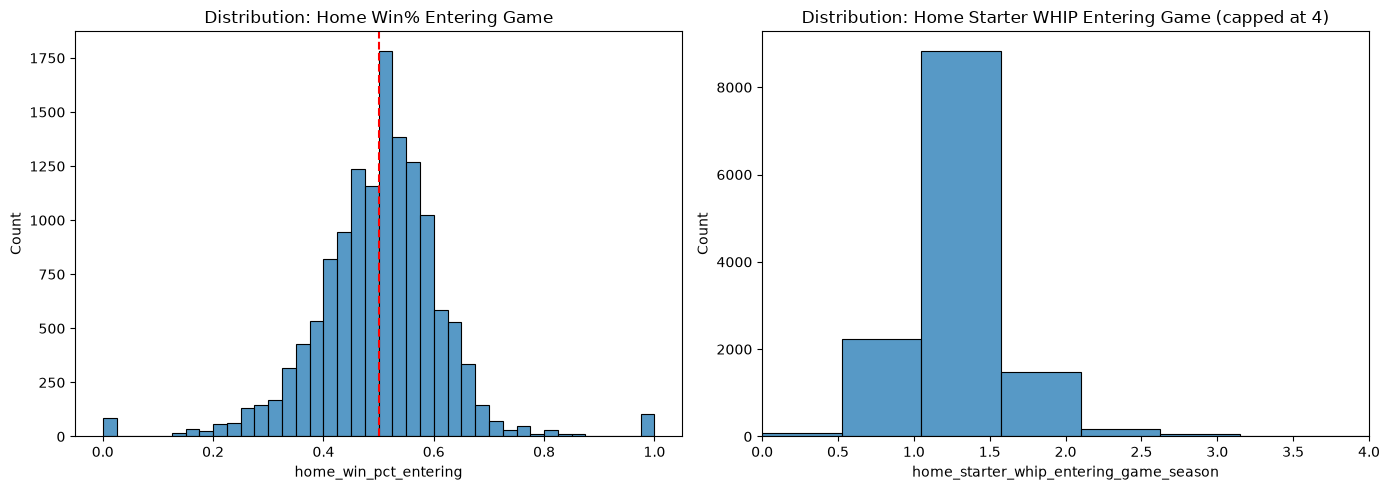

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['home_win_pct_entering'].dropna(), bins=40, ax=axes[0])
axes[0].set_title('Distribution: Home Win% Entering Game')
axes[0].axvline(0.5, color='red', linestyle='--')

sns.histplot(df['home_starter_whip_entering_game_season'].dropna(), bins=40, ax=axes[1])
axes[1].set_xlim(0, 4)
axes[1].set_title('Distribution: Home Starter WHIP Entering Game (capped at 4)')

plt.tight_layout()
plt.show()
# Win% entering game: roughly bell-shaped around 0.5, as expected for a
# rolling season-cumulative stat. BUT notice the small spikes exactly at
# 0.0 and 1.0 — these are teams very early in a season (1-2 games played),
# where win_pct_entering can only be a clean 0% or 100%, since there's no
# larger sample yet to smooth it out. This is a direct visual confirmation
# of the "noisy early-window" issue discussed during feature design —
# useful to actually SEE it for the first time, not just know about it
# abstractly.
#
# Starter WHIP entering game: bulk sits in the 1.0-1.5 range, consistent
# with real MLB league-average WHIP (~1.3) — a good sign the stat is
# computing correctly. A small tail extends toward 3-4 (same small-sample-
# size pitchers responsible for the ~21 outlier caught earlier), and a
# small spike near 0 for the same reason in the opposite direction — a
# pitcher's first start with zero hits/walks in a short outing produces an
# artificially low WHIP.